In [ ]:
import heapq
from collections import deque

graph = {
    'A': [('B', 1), ('C', 4)],
    'B': [('A', 1), ('C', 2), ('D', 5)],
    'C': [('A', 4), ('B', 2), ('D', 1)],
    'D': [('B', 5), ('C', 1)]
}


def uniform_cost_search(graph, start, goal):
    priority_queue = []
    heapq.heappush(priority_queue, (0, start, [start]))

    visited = set()

    while priority_queue:
        cost, node, path = heapq.heappop(priority_queue)

        if node in visited:
            continue

        visited.add(node)

        if node == goal:
            return path, cost

        for neighbor, weight in graph[node]:
            if neighbor not in visited:
                heapq.heappush(priority_queue, (cost + weight, neighbor, path + [neighbor]))

    return None, float('inf')

def bfs(graph, start, goal):
    queue = deque([(start, [start])])
    visited = set([start])

    while queue:
        node, path = queue.popleft()

        if node == goal:
            return path

        for neighbor, _ in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, path + [neighbor]))

    return None


if __name__ == "__main__":
    start_node = 'A'
    goal_node = 'D'

    print("Graph:")
    for node in graph:
        print(node, "->", graph[node])

    print("\n--- Uniform Cost Search ---")
    ucs_path, ucs_cost = uniform_cost_search(graph, start_node, goal_node)
    print("Path:", ucs_path)
    print("Total Cost:", ucs_cost)

    print("\n--- Breadth First Search ---")
    bfs_path = bfs(graph, start_node, goal_node)
    print("Path:", bfs_path)
    print("Number of edges:", len(bfs_path) - 1 if bfs_path else 0)


Graph:
A -> [('B', 1), ('C', 4)]
B -> [('A', 1), ('C', 2), ('D', 5)]
C -> [('A', 4), ('B', 2), ('D', 1)]
D -> [('B', 5), ('C', 1)]

--- Uniform Cost Search ---
Path: ['A', 'B', 'C', 'D']
Total Cost: 4

--- Breadth First Search ---
Path: ['A', 'B', 'D']
Number of edges: 2


Initial State:
[1, 2, 3]
[4, 0, 6]
[7, 5, 8]

Solving with H1 (Misplaced Tiles):
H1 - Total Nodes Explored: 3
H1 - Solution Depth: 2
Solution Path for H1:
[1, 2, 3]
[4, 5, 6]
[7, 0, 8]

[1, 2, 3]
[4, 5, 6]
[7, 8, 0]

Solving with H2 (Manhattan Distance):
H2 - Total Nodes Explored: 3
H2 - Solution Depth: 2
Solution Path for H2:
[1, 2, 3]
[4, 5, 6]
[7, 0, 8]

[1, 2, 3]
[4, 5, 6]
[7, 8, 0]



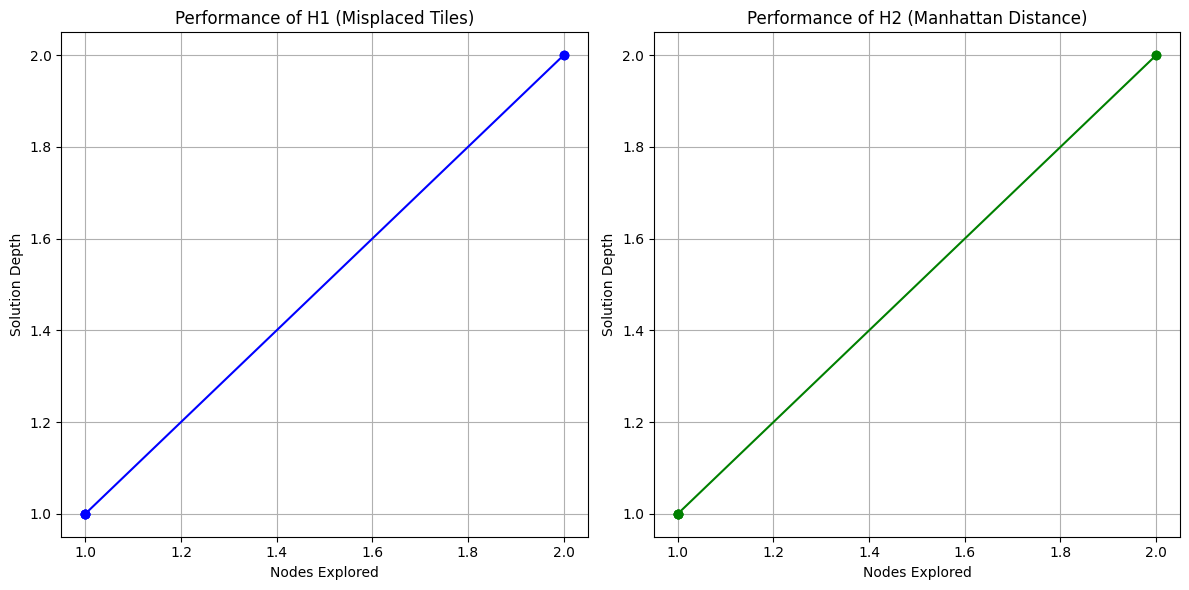

In [ ]:
import heapq

GOAL_STATE = (
    (1, 2, 3),
    (4, 5, 6),
    (7, 8, 0)
)


def heuristic_misplaced(state):
    count = 0
    for i in range(3):
        for j in range(3):
            if state[i][j] != 0 and state[i][j] != GOAL_STATE[i][j]:
                count += 1
    return count


def heuristic_manhattan(state):
    distance = 0
    for i in range(3):
        for j in range(3):
            val = state[i][j]
            if val != 0:
                goal_x = (val - 1) // 3
                goal_y = (val - 1) % 3
                distance += abs(i - goal_x) + abs(j - goal_y)
    return distance


def find_zero(state):
    for i in range(3):
        for j in range(3):
            if state[i][j] == 0:
                return i, j


def get_neighbors(state):
    x, y = find_zero(state)
    moves = [(-1,0), (1,0), (0,-1), (0,1)]
    neighbors = []

    for dx, dy in moves:
        nx, ny = x + dx, y + dy
        if 0 <= nx < 3 and 0 <= ny < 3:
            new_state = [list(row) for row in state]
            new_state[x][y], new_state[nx][ny] = new_state[nx][ny], new_state[x][y]
            neighbors.append(tuple(tuple(row) for row in new_state))

    return neighbors


def a_star(start_state, heuristic_func):
    open_list = []
    heapq.heappush(open_list, (0, start_state, 0, []))

    visited = set()
    nodes_expanded = 0

    while open_list:
        f, state, g, path = heapq.heappop(open_list)

        if state in visited:
            continue

        visited.add(state)
        nodes_expanded += 1

        if state == GOAL_STATE:
            return path + [state], nodes_expanded, g

        for neighbor in get_neighbors(state):
            if neighbor not in visited:
                h = heuristic_func(neighbor)
                heapq.heappush(open_list, (g + 1 + h, neighbor, g + 1, path + [state]))

    return None, nodes_expanded, -1


def print_state(state):
    for row in state:
        print(row)
    print()


if __name__ == "__main__":

    start_state = (
        (1, 2, 3),
        (4, 0, 6),
        (7, 5, 8)
    )

    print("Initial State:")
    print_state(start_state)

    
    path1, nodes1, depth1 = a_star(start_state, heuristic_misplaced)

    print("A* using Misplaced Tiles Heuristic (H1)")
    print("Solution Depth:", depth1)
    print("Nodes Expanded:", nodes1)

    
    path2, nodes2, depth2 = a_star(start_state, heuristic_manhattan)

    print("\nA* using Manhattan Distance Heuristic (H2)")
    print("Solution Depth:", depth2)
    print("Nodes Expanded:", nodes2)

    print("\n--- Performance Comparison ---")
    print("Heuristic\tDepth\tNodes Expanded")
    print(f"H1\t\t{depth1}\t{nodes1}")
    print(f"H2\t\t{depth2}\t{nodes2}")
